# 📱 Mobile Price Predictor Pro
## Complete ML Pipeline — From Data to Deployed Model

This notebook trains an XGBoost model to predict mobile phone
price ranges across 12 narrow bands (Under ₹5,000 to Above ₹70,000).

Steps:
1. Install Libraries
2. Import Dependencies  
3. Generate Rich Dataset (Brand, Processor, Camera, Display etc.)
4. Feature Engineering & Encoding
5. Train XGBoost Model
6. Evaluate & Save Model

In [30]:
!pip install xgboost joblib scikit-learn pandas numpy matplotlib seaborn

In [31]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [32]:
PRICE_BANDS = {
    0:  "Under ₹5,000",
    1:  "₹5,000 – ₹8,000",
    2:  "₹8,000 – ₹10,000",
    3:  "₹10,000 – ₹13,000",
    4:  "₹13,000 – ₹16,000",
    5:  "₹16,000 – ₹20,000",
    6:  "₹20,000 – ₹25,000",
    7:  "₹25,000 – ₹30,000",
    8:  "₹30,000 – ₹40,000",
    9:  "₹40,000 – ₹50,000",
    10: "₹50,000 – ₹70,000",
    11: "Above ₹70,000",
}

# Processors with performance scores
PROCESSORS = {
    "Snapdragon 8 Gen 3":   100,
    "Apple A17 Bionic":     100,
    "Dimensity 9300":        95,
    "Snapdragon 8 Gen 2":    90,
    "Apple A16 Bionic":      88,
    "Snapdragon 7s Gen 2":   75,
    "Dimensity 8200":        72,
    "Exynos 1380":           65,
    "Snapdragon 695":        50,
    "Dimensity 700":         45,
    "Helio G99":             42,
    "Helio G85":             25,
    "Snapdragon 480":        28,
    "Unisoc T610":           20,
}

# Brands with market share weights
BRANDS_W = {
    "Samsung":  0.18, "Apple":    0.12, "OnePlus":  0.10,
    "Xiaomi":   0.15, "Realme":   0.12, "Vivo":     0.10,
    "Oppo":     0.10, "Nokia":    0.08, "Motorola": 0.05,
}

print("✅ Specs defined!")
print(f"Total Processors: {len(PROCESSORS)}")
print(f"Total Brands: {len(BRANDS_W)}")

✅ Specs defined!
Total Processors: 14
Total Brands: 9


In [33]:
np.random.seed(42)
N = 2000

proc_list   = list(PROCESSORS.keys())
proc_scores = np.array(list(PROCESSORS.values()))
proc_w      = proc_scores / proc_scores.sum()

brand_col       = np.random.choice(list(BRANDS_W.keys()), N, p=list(BRANDS_W.values()))
processor_col   = np.random.choice(proc_list, N, p=proc_w)
processor_score = np.array([PROCESSORS[p] for p in processor_col])

ram               = np.random.choice([2048,3072,4096,6144,8192,12288,16384], N, p=[0.05,0.10,0.20,0.25,0.20,0.15,0.05])
internal_memory   = np.random.choice([32,64,128,256,512,1024], N, p=[0.05,0.15,0.35,0.25,0.15,0.05])
battery_power     = np.random.randint(3000, 6001, N)
n_cores           = np.random.choice([4,6,8], N, p=[0.2,0.3,0.5])
clock_speed       = np.round(np.random.uniform(1.8, 3.2, N), 1)
primary_cam       = np.random.choice([12,48,50,64,108,200], N, p=[0.10,0.20,0.25,0.20,0.15,0.10])
front_cam         = np.random.choice([8,16,20,32,50],       N, p=[0.15,0.30,0.25,0.20,0.10])
ois               = np.random.randint(0, 2, N)
night_mode        = np.random.randint(0, 2, N)
periscope_zoom    = np.random.choice([0,1], N, p=[0.7,0.3])
refresh_rate      = np.random.choice([60,90,120,144], N, p=[0.20,0.25,0.35,0.20])
five_g            = np.random.choice([0,1], N, p=[0.3,0.7])
wifi_6            = np.random.choice([0,1], N, p=[0.4,0.6])
nfc               = np.random.choice([0,1], N, p=[0.3,0.7])
fast_charging     = np.random.choice([0,18,33,45,67,100,120], N, p=[0.05,0.10,0.20,0.25,0.20,0.10,0.10])
wireless_charging = np.random.choice([0,1], N, p=[0.5,0.5])
mobile_wt         = np.random.randint(150, 230, N)
display_type      = np.random.choice(["AMOLED","Super AMOLED","IPS LCD","LTPO AMOLED"], N, p=[0.30,0.25,0.25,0.20])
fingerprint       = np.random.choice(["None","Side","In-display","Rear"], N, p=[0.05,0.30,0.40,0.25])

df = pd.DataFrame({
    "brand":brand_col, "processor":processor_col,
    "processor_score":processor_score, "ram":ram,
    "internal_memory":internal_memory, "battery_power":battery_power,
    "n_cores":n_cores, "clock_speed":clock_speed,
    "primary_cam":primary_cam, "front_cam":front_cam,
    "ois":ois, "night_mode":night_mode, "periscope_zoom":periscope_zoom,
    "refresh_rate":refresh_rate, "five_g":five_g, "wifi_6":wifi_6,
    "nfc":nfc, "fast_charging":fast_charging,
    "wireless_charging":wireless_charging, "mobile_wt":mobile_wt,
    "display_type":display_type, "fingerprint":fingerprint,
})

print(f"✅ Dataset created: {df.shape}")
print(f"Features: {df.shape[1]}")
df.head()

✅ Dataset created: (2000, 22)
Features: 22


,brand,processor,processor_score,ram,internal_memory,battery_power,n_cores,clock_speed,primary_cam,front_cam,...,periscope_zoom,refresh_rate,five_g,wifi_6,nfc,fast_charging,wireless_charging,mobile_wt,display_type,fingerprint
0,OnePlus,Dimensity 9300,95,6144,256,5717,8,2.0,12,16,...,0,120,1,1,0,120,0,184,LTPO AMOLED,In-display
1,Motorola,Dimensity 9300,95,12288,64,4897,8,2.3,50,16,...,1,120,1,0,1,18,0,216,LTPO AMOLED,Rear
2,Vivo,Helio G99,42,8192,512,4674,8,3.0,64,8,...,1,120,1,1,1,0,1,214,LTPO AMOLED,Rear
3,Realme,Dimensity 9300,95,4096,256,5268,4,2.3,64,32,...,0,90,1,0,1,18,0,166,IPS LCD,In-display
4,Samsung,Dimensity 9300,95,3072,64,3272,8,3.1,50,32,...,0,120,0,0,1,18,0,191,IPS LCD,In-display


In [34]:
score = (
    (df["processor_score"] / 100) * 35 +
    (df["ram"] / 16384) * 20 +
    (df["internal_memory"] / 1024) * 8 +
    (df["primary_cam"] / 200) * 7 +
    df["five_g"] * 5 +
    (df["refresh_rate"] / 144) * 5 +
    (df["fast_charging"] / 120) * 5 +
    df["ois"] * 3 +
    df["wireless_charging"] * 3 +
    df["periscope_zoom"] * 3 +
    df["wifi_6"] * 2 +
    df["nfc"] * 2 +
    (df["battery_power"] / 6000) * 2 +
    np.random.uniform(0, 5, N)
)
score = (score - score.min()) / (score.max() - score.min()) * 100

# 4 Price Bands
PRICE_BANDS = {
    0: "💚 Budget  — Under ₹10,000",
    1: "💙 Mid Range — ₹10,000 – ₹25,000",
    2: "🧡 High End — ₹25,000 – ₹55,000",
    3: "👑 Premium — Above ₹55,000",
}

df["price_band"] = pd.cut(
    score,
    bins=[0, 25, 50, 75, 101],
    labels=[0, 1, 2, 3]
)
df["price_band"] = df["price_band"].cat.codes
df = df[df["price_band"] >= 0].reset_index(drop=True)

print("✅ Price bands created!")
print("\nDistribution:")
print(df["price_band"].map(PRICE_BANDS).value_counts().sort_index())

✅ Price bands created!

Distribution:
price_band
👑 Premium — Above ₹55,000           250
💙 Mid Range — ₹10,000 – ₹25,000     551
💚 Budget  — Under ₹10,000           108
🧡 High End — ₹25,000 – ₹55,000     1090
Name: count, dtype: int64


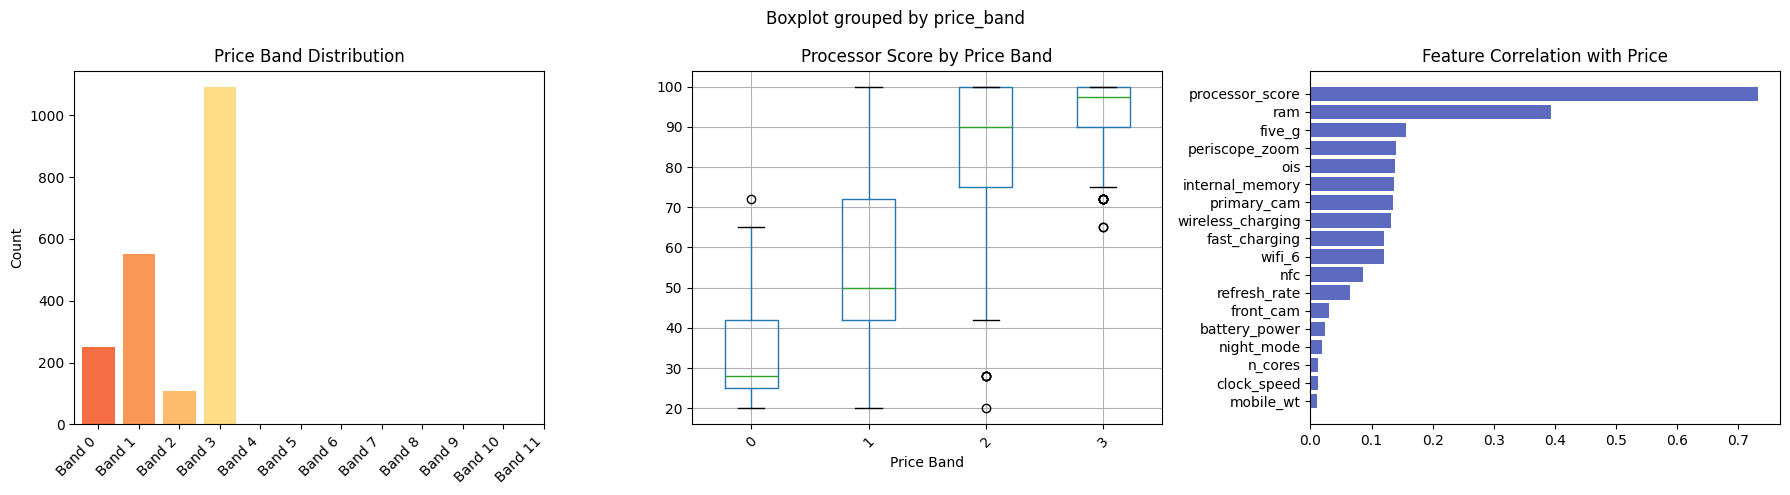

✅ EDA complete!


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mobile Price Predictor — EDA", fontsize=15, fontweight="bold")

# Price band distribution
counts = df["price_band"].map(PRICE_BANDS).value_counts().sort_index()
axes[0].bar(range(len(counts)), counts.values, color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 12)))
axes[0].set_xticks(range(12))
axes[0].set_xticklabels([f"Band {i}" for i in range(12)], rotation=45, ha="right")
axes[0].set_title("Price Band Distribution")
axes[0].set_ylabel("Count")

# Processor score vs price
df.boxplot(column="processor_score", by="price_band", ax=axes[1])
axes[1].set_title("Processor Score by Price Band")
axes[1].set_xlabel("Price Band")
plt.sca(axes[1])
plt.xticks(rotation=45)

# Feature correlation with price
corr = df.select_dtypes(include=[np.number]).corr()["price_band"].abs()
corr = corr.drop("price_band").sort_values(ascending=True)
axes[2].barh(corr.index, corr.values, color="#5C6BC0")
axes[2].set_title("Feature Correlation with Price")

plt.tight_layout()
plt.show()
print("✅ EDA complete!")

In [36]:
le_brand       = LabelEncoder().fit(df["brand"])
le_processor   = LabelEncoder().fit(df["processor"])
le_display     = LabelEncoder().fit(df["display_type"])
le_fingerprint = LabelEncoder().fit(df["fingerprint"])

df["brand_enc"]       = le_brand.transform(df["brand"])
df["processor_enc"]   = le_processor.transform(df["processor"])
df["display_enc"]     = le_display.transform(df["display_type"])
df["fingerprint_enc"] = le_fingerprint.transform(df["fingerprint"])

FEATURES = [
    "processor_score", "ram", "internal_memory", "battery_power",
    "n_cores", "clock_speed", "primary_cam", "front_cam",
    "ois", "night_mode", "periscope_zoom", "refresh_rate",
    "five_g", "wifi_6", "nfc", "fast_charging", "wireless_charging",
    "mobile_wt", "brand_enc", "processor_enc", "display_enc", "fingerprint_enc"
]

X = df[FEATURES]
y = df["price_band"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Encoding complete!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Total features   : {X_train.shape[1]}")

✅ Encoding complete!
Training samples : 1599
Testing samples  : 400
Total features   : 22


In [39]:
print("🏋️ Training XGBoost model on", N, "samples...")
print("This may take 1-2 minutes...")

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0
)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
cv  = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy").mean()

print(f"\n✅ Training complete!")
print(f"Test Accuracy : {acc:.2%}")
print(f"CV Accuracy   : {cv:.2%}")

🏋️ Training XGBoost model on 2000 samples...
This may take 1-2 minutes...

✅ Training complete!
Test Accuracy : 77.25%
CV Accuracy   : 82.18%


📊 Classification Report:

                       precision    recall  f1-score   support

  Budget (Under ₹10K)       0.75      0.55      0.63        22
Mid Range (₹10K-₹25K)       0.73      0.75      0.74       110
 High End (₹25K-₹55K)       0.79      0.88      0.83       218
 Premium (Above ₹55K)       0.79      0.46      0.58        50

             accuracy                           0.77       400
            macro avg       0.77      0.66      0.70       400
         weighted avg       0.77      0.77      0.76       400



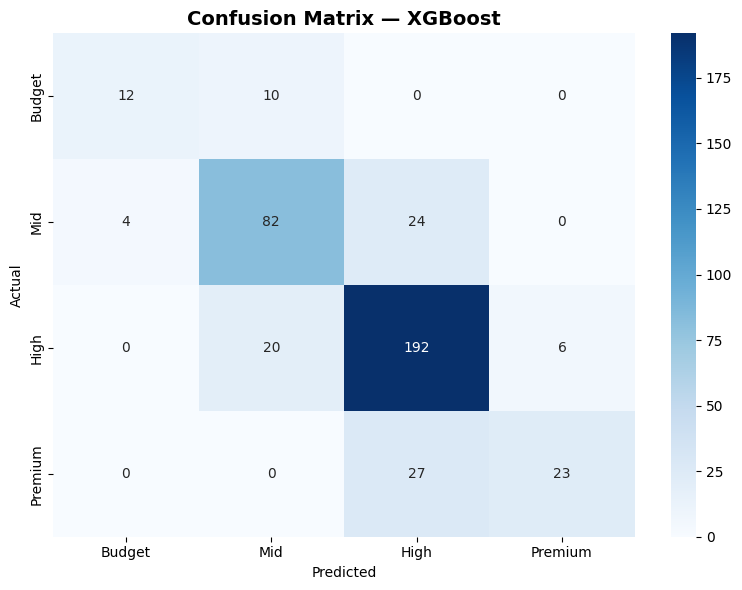

In [38]:
y_pred = model.predict(X_test)

print("📊 Classification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=[
        "Budget (Under ₹10K)",
        "Mid Range (₹10K-₹25K)",
        "High End (₹25K-₹55K)",
        "Premium (Above ₹55K)"
    ]
))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Budget","Mid","High","Premium"],
            yticklabels=["Budget","Mid","High","Premium"])
plt.title("Confusion Matrix — XGBoost", fontsize=14, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [40]:
joblib.dump({
    "model":          model,
    "accuracy":       acc,
    "le_brand":       le_brand,
    "le_processor":   le_processor,
    "le_display":     le_display,
    "le_fingerprint": le_fingerprint,
    "features":       FEATURES,
    "price_bands":    PRICE_BANDS,
    "n_bands":        4
}, "model_bundle.pkl")

print("💾 model_bundle.pkl saved!")
print(f"✅ Accuracy: {acc:.2%}")
print("\n📥 Download Instructions:")
print("  1. Click the 📁 folder icon on the LEFT sidebar")
print("  2. Right click on model_bundle.pkl")
print("  3. Click Download")
print("\n📤 Then upload model_bundle.pkl to your GitHub repository!")

💾 model_bundle.pkl saved!
✅ Accuracy: 77.25%

📥 Download Instructions:
  1. Click the 📁 folder icon on the LEFT sidebar
  2. Right click on model_bundle.pkl
  3. Click Download

📤 Then upload model_bundle.pkl to your GitHub repository!


# New Section